In [50]:
!pip install lifelines

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4048 sha256=53b7f019cebab087d06f85cd8708c699760fe29d11064ff779594016cde9d252
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\7e\16\46\9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma

   ---------------------------------------- 0/5 [interface-meta]
   -------- ------------------------------- 1/5 [autograd]
   -------- ------------------------------- 1/5 [autograd]
   -------- ------------------------------- 1/5 [autograd]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --

  DEPRECATION: Building 'autograd-gamma' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'autograd-gamma'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

from lifelines import KaplanMeierFitter

In [18]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Breast Cancer METABRIC (1).csv")

In [19]:
df.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      2509 non-null   object 
 1   Age at Diagnosis                2498 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     2509 non-null   object 
 4   Cancer Type Detailed            2509 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          2498 non-null   float64
 9   ER status measured by IHC       2426 non-null   object 
 10  ER Status                       2469 non-null   object 
 11  Neoplasm Histologic Grade       2388 non-null   float64
 12  HER2 status measured by SNP6    19

In [21]:
print(df.columns.tolist())


['Patient ID', 'Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC', 'ER Status', 'Neoplasm Histologic Grade', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'PR Status', 'Radio Therapy', 'Relapse Free Status (Months)', 'Relapse Free Status', 'Sex', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage', "Patient's Vital Status"]


In [22]:
df.isnull().sum()

Patient ID                          0
Age at Diagnosis                   11
Type of Breast Surgery            554
Cancer Type                         0
Cancer Type Detailed                0
Cellularity                       592
Chemotherapy                      529
Pam50 + Claudin-low subtype       529
Cohort                             11
ER status measured by IHC          83
ER Status                          40
Neoplasm Histologic Grade         121
HER2 status measured by SNP6      529
HER2 Status                       529
Tumor Other Histologic Subtype    135
Hormone Therapy                   529
Inferred Menopausal State         529
Integrative Cluster               529
Primary Tumor Laterality          639
Lymph nodes examined positive     266
Mutation Count                    152
Nottingham prognostic index       222
Oncotree Code                       0
Overall Survival (Months)         528
Overall Survival Status           528
PR Status                         529
Radio Therap

In [23]:
df = df.dropna()

In [24]:
df.isnull().sum()

Patient ID                        0
Age at Diagnosis                  0
Type of Breast Surgery            0
Cancer Type                       0
Cancer Type Detailed              0
Cellularity                       0
Chemotherapy                      0
Pam50 + Claudin-low subtype       0
Cohort                            0
ER status measured by IHC         0
ER Status                         0
Neoplasm Histologic Grade         0
HER2 status measured by SNP6      0
HER2 Status                       0
Tumor Other Histologic Subtype    0
Hormone Therapy                   0
Inferred Menopausal State         0
Integrative Cluster               0
Primary Tumor Laterality          0
Lymph nodes examined positive     0
Mutation Count                    0
Nottingham prognostic index       0
Oncotree Code                     0
Overall Survival (Months)         0
Overall Survival Status           0
PR Status                         0
Radio Therapy                     0
Relapse Free Status (Months)

Exploratory Data Analysis (EDA)

Age Distribution

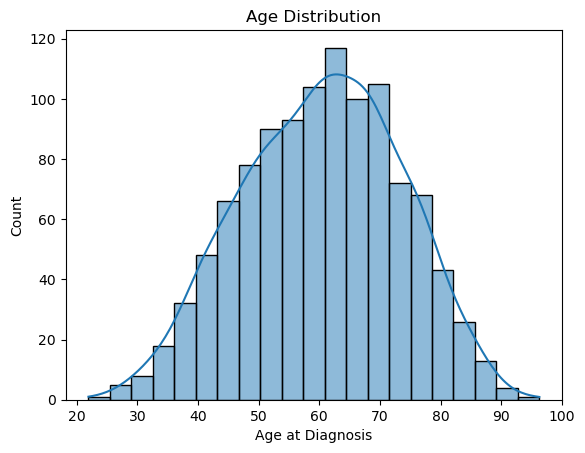

In [25]:
sns.histplot(df['Age at Diagnosis'], kde=True)
plt.title('Age Distribution')
plt.show()

Tumor Size VS Survival

In [26]:
df.columns


Index(['Patient ID', 'Age at Diagnosis', 'Type of Breast Surgery',
       'Cancer Type', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy',
       'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC',
       'ER Status', 'Neoplasm Histologic Grade',
       'HER2 status measured by SNP6', 'HER2 Status',
       'Tumor Other Histologic Subtype', 'Hormone Therapy',
       'Inferred Menopausal State', 'Integrative Cluster',
       'Primary Tumor Laterality', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code',
       'Overall Survival (Months)', 'Overall Survival Status', 'PR Status',
       'Radio Therapy', 'Relapse Free Status (Months)', 'Relapse Free Status',
       'Sex', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage',
       'Patient's Vital Status'],
      dtype='object')

In [27]:
[col for col in df.columns if 'surviv' in col.lower() or 'death' in col.lower() or 'status' in col.lower()]


['ER status measured by IHC',
 'ER Status',
 'HER2 status measured by SNP6',
 'HER2 Status',
 'Overall Survival (Months)',
 'Overall Survival Status',
 'PR Status',
 'Relapse Free Status (Months)',
 'Relapse Free Status',
 "Patient's Vital Status"]

In [28]:
df.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease
5,MB-0010,78.77,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,No,LumB,1.0,Positve,...,Deceased,Positive,Yes,2.89,Recurred,Female,ER+/HER2- High Prolif,31.0,4.0,Died of Disease
10,MB-0028,86.41,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,No,LumB,1.0,Positve,...,Deceased,Negative,Yes,36.09,Not Recurred,Female,ER+/HER2- High Prolif,16.0,2.0,Died of Other Causes
11,MB-0035,84.22,Mastectomy,Breast Cancer,Breast Invasive Lobular Carcinoma,High,No,Her2,1.0,Negative,...,Deceased,Negative,No,35.79,Recurred,Female,ER+/HER2- High Prolif,28.0,2.0,Died of Disease


In [32]:
df['Patient\'s Vital Status'].value_counts()

Patient's Vital Status
Living                  484
Died of Disease         370
Died of Other Causes    238
Name: count, dtype: int64

In [40]:
df['overall_survival'] = df['Patient\'s Vital Status'].map({
    'Living':0,
    'Died of Disease':1,
    'Died of Other Causes':1 
})


In [41]:
df['overall_survival'].head()

1     0
4     1
5     1
10    1
11    1
Name: overall_survival, dtype: int64

Correlation Heatmap

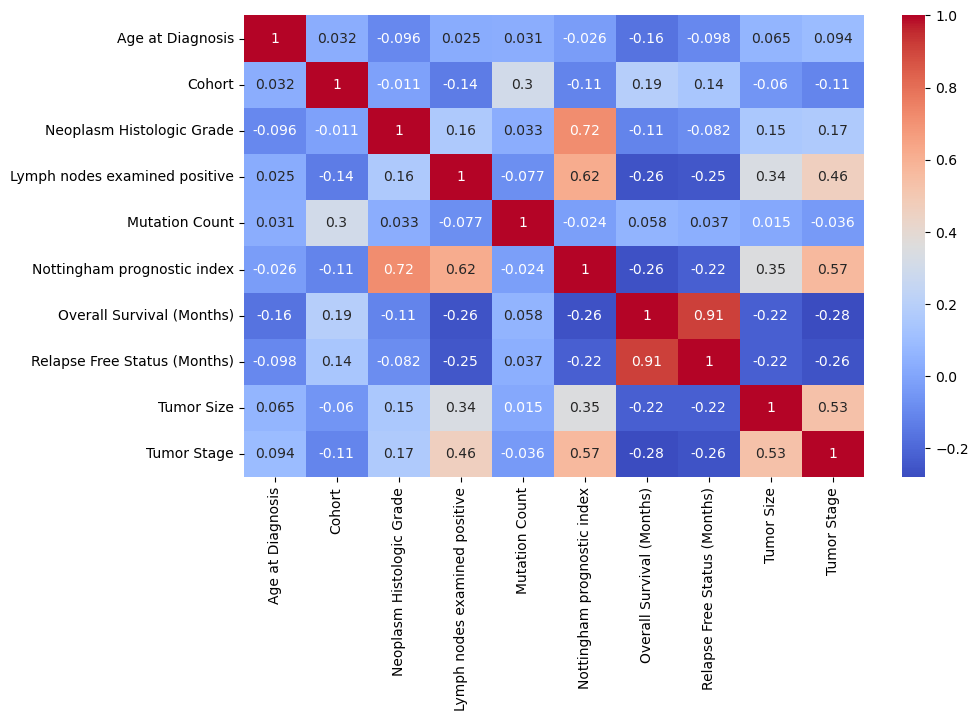

In [44]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='float64').corr(), annot=True, cmap='coolwarm')
plt.show()

Feature Scaling

In [46]:
features = ['Age at Diagnosis', 'Tumor Size', 'Lymph nodes examined positive']
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

Survival Analysis  

Kaplan Meier Survival Curve

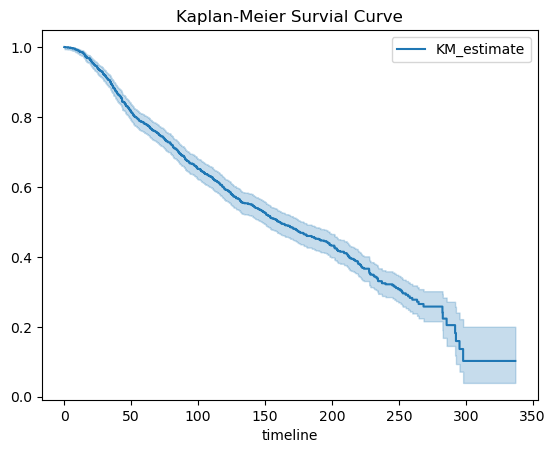

In [55]:
kmf = KaplanMeierFitter()
kmf.fit(df['Overall Survival (Months)'], df['overall_survival'])
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survial Curve')
plt.show()

Cox Proportional Hazards Model 

In [58]:
from lifelines import CoxPHFitter
cox_df = df[['Overall Survival (Months)','overall_survival'] + features]
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='Overall Survival (Months)', event_col='overall_survival')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1092 total observations, 484 right-censored observations>
             duration col = 'Overall Survival (Months)'
                event col = 'overall_survival'
      baseline estimation = breslow
   number of observations = 1092
number of events observed = 608
   partial log-likelihood = -3744.37
         time fit was run = 2026-02-07 08:04:44 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Age at Diagnosis               0.45      1.57      0.05            0.36            0.54                1.44                1.72
Tumor Size                     0.15      1.17      0.03            0.09            0.21                1.10                1.24
Lymph nodes examined positive  0.27      1.31      0.04            0.20            0.34                1.22                1.41

                               cmp to    z      p  -log2(p)
covariate                                                  
Age at Diagnosis                 0.00 9.82 <0.005     73.19
Tumor Size                       0.00 5.01 <0.005     20.83
Lymph nodes examined positive    0.00 7.39 <0.005     42.66
---
Concordance = 0.65
Partial AIC = 7494.73
log-likelihood ratio test = 201.27 on 3 df
-log2(p) of ll-ratio test = 141.68

Train Test Split

In [59]:
X = df[features]
y = df['overall_survival']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic Regression 

In [60]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, lr_pred))
print('ROC-AUC:', roc_auc_score(y_test, lr_prob))

Accuracy: 0.6529680365296804
ROC-AUC: 0.714516129032258


Support Vector Machine

In [61]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_prob = svm.predict_proba(X_test)[:,1]


print('Accuracy:', accuracy_score(y_test, svm_pred))
print('ROC-AUC:', roc_auc_score(y_test, svm_prob))

Accuracy: 0.6438356164383562
ROC-AUC: 0.7217741935483871


Decision Tree

In [62]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]


print('Accuracy:', accuracy_score(y_test, dt_pred))
print('ROC-AUC:', roc_auc_score(y_test, dt_prob))

Accuracy: 0.6164383561643836
ROC-AUC: 0.6120543293718166


ROC Curve Comparison

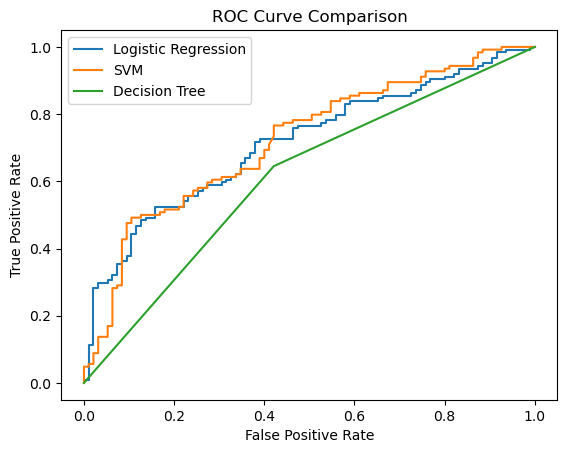

In [63]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)


plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_svm, tpr_svm, label='SVM')
plt.plot(fpr_dt, tpr_dt, label='Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve Comparison')
plt.show()